# U.S. Presidential and Senate Election Analysis (1976–2020)

This project analyzes U.S. Presidential and Senate election data from 1976 to 2020. The data was cleaned by handling missing values, correcting data types, removing duplicates, standardizing text, and checking for invalid records. The analysis then looks at national presidential vote share, Senate seat share, split ticket voting, and presidential winning margins to understand how election results changed over time.

In [120]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pres_raw = pd.read_csv(
    "/kaggle/input/datasets/manishamali/us-election-analysis-dataset/1976-2020-president.csv",encoding="latin-1"
)

sen_raw = pd.read_csv(
    "/kaggle/input/datasets/manishamali/us-election-analysis-dataset/1976-2020-senate.csv",encoding="latin-1"
)

print("President data:", pres_raw.shape)
print("Senate data:", sen_raw.shape)

President data: (4287, 15)
Senate data: (3629, 19)


**Data Cleaning**

In [121]:
print(pres_raw.info())
print(sen_raw.info())
print("Presidential missing values")
print(pres_raw.isnull().sum())
print("Senate missing values")
print(sen_raw.isnull().sum())
print("Presidential duplicates:", pres_raw.duplicated().sum())
print("Senate duplicates:", sen_raw.duplicated().sum())

pres = pres_raw.copy()
sen = sen_raw.copy()

pres.columns = (pres.columns.str.strip().str.lower().str.replace(" ", "_"))
sen.columns = (sen.columns.str.strip().str.lower().str.replace(" ", "_"))

# Clean text columns
for col in pres.select_dtypes(include="object").columns:
    pres[col] = pres[col].apply(
        lambda x: x.strip() if isinstance(x, str) else x
    )
    pres[col] = pres[col].replace("", pd.NA)

for col in sen.select_dtypes(include="object").columns:
    sen[col] = sen[col].apply(
        lambda x: x.strip() if isinstance(x, str) else x
    )
    sen[col] = sen[col].replace("", pd.NA)

# Convert numeric columns
pres["year"] = pd.to_numeric(pres["year"], errors="coerce").astype("Int64")
pres["state_fips"] = pd.to_numeric(pres["state_fips"], errors="coerce").astype("Int64")
pres["state_cen"] = pd.to_numeric(pres["state_cen"], errors="coerce").astype("Int64")
pres["state_ic"] = pd.to_numeric(pres["state_ic"], errors="coerce").astype("Int64")
pres["candidatevotes"] = pd.to_numeric(
    pres["candidatevotes"], errors="coerce"
).astype("Int64")
pres["totalvotes"] = pd.to_numeric(
    pres["totalvotes"], errors="coerce"
).astype("Int64")


sen["year"] = pd.to_numeric(sen["year"], errors="coerce").astype("Int64")
sen["state_fips"] = pd.to_numeric(sen["state_fips"], errors="coerce").astype("Int64")
sen["state_cen"] = pd.to_numeric(sen["state_cen"], errors="coerce").astype("Int64")
sen["state_ic"] = pd.to_numeric(sen["state_ic"], errors="coerce").astype("Int64")
sen["candidatevotes"] = pd.to_numeric(
    sen["candidatevotes"], errors="coerce"
).astype("Int64")
sen["totalvotes"] = pd.to_numeric(
    sen["totalvotes"], errors="coerce"
).astype("Int64")

# Convert boolean columns
pres["writein"] = pres["writein"].astype("boolean")
sen["writein"] = sen["writein"].astype("boolean")
sen["special"] = sen["special"].astype("boolean")
sen["unofficial"] = sen["unofficial"].astype("boolean")

# Check missing values after datatype conversion
print("Presidential missing values after cleaning")
print(pres.isnull().sum())

print("Senate missing values after cleaning")
print(sen.isnull().sum())

# Remove completely empty notes column
if "notes" in pres.columns and pres["notes"].isna().all():
    pres = pres.drop(columns="notes")

# Keep required years
pres = pres[pres["year"].between(1976, 2020)].copy()
sen = sen[sen["year"].between(1976, 2020)].copy()

# Standardize Senate election stage
sen["stage"] = sen["stage"].apply(
    lambda x: x.strip().lower() if isinstance(x, str) else x
)

sen = sen[sen["stage"].isin(["gen", "runoff"])].copy()


# Remove Georgia pre-election records
sen = sen[~((sen["state"] == "GEORGIA") & (sen["stage"] == "pre"))].copy()

# Remove Georgia 2020 first-round general election records
sen = sen[~(
        (sen["state"] == "GEORGIA") & (sen["year"] == 2020) &
        (sen["stage"] == "gen") & (~sen["special"]))].copy()

# Correct Wyoming 2020 party names
sen.loc[
    (sen["state"] == "WYOMING") & (sen["year"] == 2020) &
    (sen["candidate"] == "CYNTHIA M. LUMMIS"),"party_simplified"
] = "REPUBLICAN"

sen.loc[
    (sen["state"] == "WYOMING") & (sen["year"] == 2020) &
    (sen["candidate"] == "MERAV BEN DAVID"),"party_simplified"
] = "DEMOCRAT"

# Identify administrative vote records
admin_labels = [
    "OTHER","SCATTER","SCATTERED","UNDER VOTE","UNDER VOTES","OVER VOTE",
    "OVER VOTES","BLANK VOTE","BLANK VOTES"
]

sen["admin_vote"] = (sen["candidate"].fillna("")
    .apply(lambda x: x.upper() in admin_labels if isinstance(x, str) else False)
)

# Check for invalid negative votes
pres = pres[pres["candidatevotes"] >= 0].copy()
sen = sen[sen["candidatevotes"] >= 0].copy()

# Total votes should be greater than zero
pres = pres[pres["totalvotes"] > 0].copy()
sen = sen[sen["totalvotes"] > 0].copy()

# Check whether candidate votes exceed total votes
invalid_pres = pres[pres["candidatevotes"] > pres["totalvotes"]]

invalid_sen = sen[sen["candidatevotes"] > sen["totalvotes"]]
print("Invalid presidential records:", len(invalid_pres))
print("Invalid Senate records:", len(invalid_sen))

# Remove exact duplicate rows
pres = pres.drop_duplicates().copy()
sen = sen.drop_duplicates().copy()

# Check presidential vote totals
pres_check = (
    pres.groupby(["year", "state"], dropna=False).agg(
        candidate_votes=("candidatevotes", "sum"),total_votes=("totalvotes", "first")
    )
)

pres_check["difference"] = (pres_check["total_votes"] - pres_check["candidate_votes"])

print("Presidential vote total differences:",(pres_check["difference"] != 0).sum())

# Check Senate vote totals
sen_check = (sen.groupby(["year", "state", "stage", "special"],dropna=False)
    .agg(candidate_votes=("candidatevotes", "sum"),total_votes=("totalvotes", "first")))

sen_check["difference"] = (sen_check["total_votes"] - sen_check["candidate_votes"])

print("Senate vote total differences:",(sen_check["difference"] != 0).sum())

print("Final presidential shape:", pres.shape)
print("Final Senate shape:", sen.shape)
print("Final presidential missing values")
print(pres.isnull().sum())
print("Final Senate missing values")
print(sen.isnull().sum())
print("Presidential duplicates:", pres.duplicated().sum())
print("Senate duplicates:", sen.duplicated().sum())
print("Presidential data types")
print(pres.dtypes)
print("Senate data types")
print(sen.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4287 entries, 0 to 4286
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              4287 non-null   int64  
 1   state             4287 non-null   object 
 2   state_po          4287 non-null   object 
 3   state_fips        4287 non-null   int64  
 4   state_cen         4287 non-null   int64  
 5   state_ic          4287 non-null   int64  
 6   office            4287 non-null   object 
 7   candidate         4000 non-null   object 
 8   party_detailed    3831 non-null   object 
 9   writein           4284 non-null   object 
 10  candidatevotes    4287 non-null   int64  
 11  totalvotes        4287 non-null   int64  
 12  version           4287 non-null   int64  
 13  notes             0 non-null      float64
 14  party_simplified  4287 non-null   object 
dtypes: float64(1), int64(7), object(7)
memory usage: 502.5+ KB
None
<class 'pandas.core.frame

*The data was cleaned and checked for missing values, duplicates, incorrect data types, and invalid vote values. Text fields were standardized, unnecessary columns were removed, and election stages and years were filtered. Missing values were not aggressively imputed to avoid changing the original election data. Special cases such as Georgia and Wyoming records were also corrected for accurate analysis.*

**Number of Senate races per year**

In [122]:
# Number of Senate races per year
races_per_cycle = sen.drop_duplicates(
    ["year", "state", "special"]
).groupby("year").size()

print(races_per_cycle)

year
1976    33
1978    35
1980    33
1982    33
1984    33
1986    34
1988    33
1990    35
1992    35
1994    35
1996    34
1998    34
2000    34
2002    34
2004    34
2006    33
2008    35
2010    37
2012    33
2014    36
2016    34
2018    35
2020    34
dtype: int64


*The number of Senate election records varies across election years, ranging from 33 to 37. The variation is mainly due to differences in the number of Senate elections held in each year, including special elections and other election-specific changes.*

**National Presidential Vote Share by Party (1976–2020)**

In [123]:
votes = pres.groupby(["year", "party_simplified"])["candidatevotes"].sum().unstack(fill_value=0)

vote_share = votes.div(votes.sum(axis=1), axis=0) * 100

print(vote_share.round(1))

party_simplified  DEMOCRAT  LIBERTARIAN  OTHER  REPUBLICAN
year                                                      
1976                  49.9          0.1    2.4        47.6
1980                  41.0          1.0    7.5        50.5
1984                  40.4          0.2    0.9        58.5
1988                  45.5          0.4    0.9        53.1
1992                  42.9          0.3   19.8        37.1
1996                  49.1          0.5   10.0        40.5
2000                  48.1          0.4    3.9        47.6
2004                  48.1          0.3    1.0        50.6
2008                  52.8          0.4    1.5        45.4
2012                  50.9          0.9    1.2        47.0
2016                  48.0          3.0    3.1        45.8
2020                  51.3          1.1    0.8        46.8


*The Democratic and Republican parties received the largest share of votes in most elections. Republican vote share was highest in 1984 at 58.5%, while Democratic vote share was highest in 2008 at 52.8%. The 1992 election had a relatively high share of votes for other parties at 19.8%.*

**Presidential Vote Share by Year**

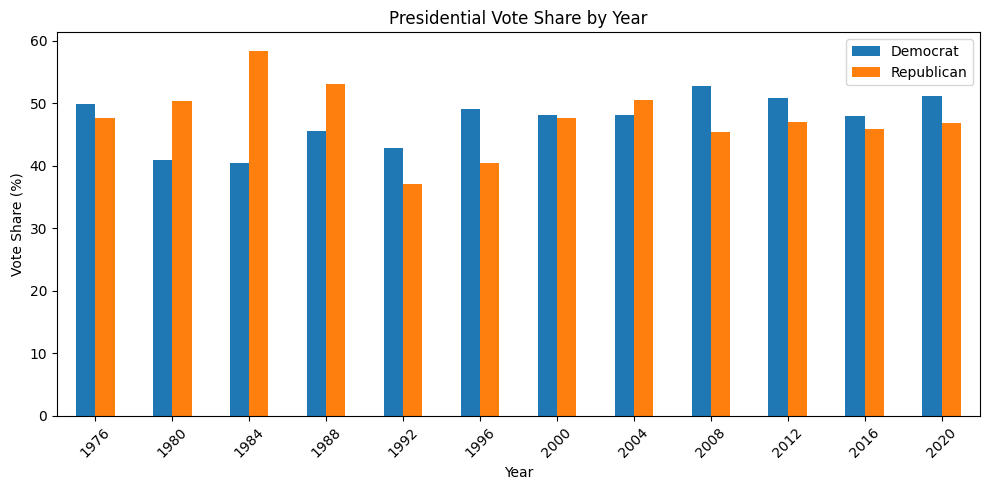

In [124]:
share = q1[["DEMOCRAT", "REPUBLICAN"]].mul(100)

share.columns = ["Democrat", "Republican"]

share.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Presidential Vote Share by Year")
plt.xlabel("Year")
plt.ylabel("Vote Share (%)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

*The chart shows that Democratic and Republican vote shares changed across election years. Republicans had a higher vote share in 1980, 1984, 1988, and 2004, while Democrats had a higher share in several other years. The largest Republican share was in 1984 (58.5%), while the highest Democratic share was in 2008 (52.8%). In 2000, the two parties had very similar vote shares.*

**Split Ticket Voting by Year**

In [125]:
# Find the presidential winner for each state and year
pres_winner = pres.loc[pres.groupby(["year", "state"])["candidatevotes"].idxmax(),
    ["year", "state", "party_simplified", "candidate"]]

pres_winner.columns = ["year", "state", "pres_party", "pres_candidate"]

# Find the Senate winner for each state and year
sen_winner = sen.loc[sen.groupby(["year", "state", "special"])["candidatevotes"].idxmax(),
    ["year", "state", "special", "party_simplified", "candidate"]]

sen_winner.columns = ["year", "state", "special", "sen_party", "sen_candidate"]

# Compare presidential and Senate winners
result = sen_winner.merge(pres_winner,on=["year", "state"])

# Check whether the presidential and Senate parties were different
result["different_party"] = (result["pres_party"] != result["sen_party"])

# Calculate the percentage of split-ticket results by year
split_rate = (result.groupby("year")["different_party"].mean() * 100)
print(split_rate.round(1))

year
1976    42.4
1980    39.4
1984    54.5
1988    51.5
1992    31.4
1996    29.4
2000    29.4
2004    20.6
2008    20.0
2012    24.2
2016     0.0
2020     2.9
Name: different_party, dtype: float64


*Split ticket voting was relatively high in earlier election years, with the highest level in 1984 at 54.5%. It gradually decreased over time and reached 0% in 2016. In 2020, the rate was only 2.9%, showing that presidential and Senate winners were from different parties much less often in the later years.*

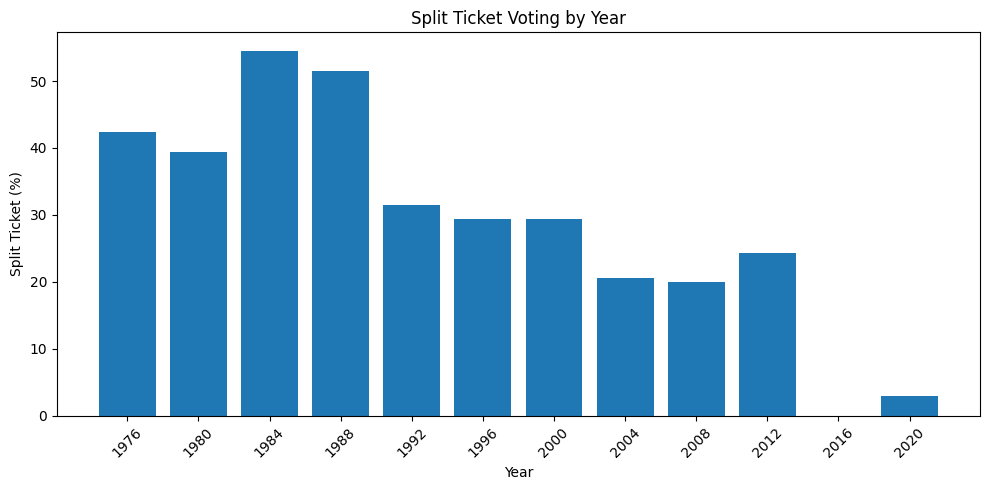

In [126]:
plt.figure(figsize=(10, 5))

plt.bar(split_rate.index.astype(str), split_rate)

plt.title("Split Ticket Voting by Year")
plt.xlabel("Year")
plt.ylabel("Split Ticket (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Median Winning Margin in Presidential Elections**

In [127]:
results = []

for (year, state), data in pres.groupby(["year", "state"]):
    data = data[data["candidate"].notna()].copy()
    admin_labels = ["OTHER", "SCATTER", "SCATTERED","UNDER VOTE", "UNDER VOTES",
        "OVER VOTE", "OVER VOTES","BLANK VOTE", "BLANK VOTES"]
    data = data[~data["candidate"].str.upper().isin(admin_labels)]

    data = data.sort_values("candidatevotes",ascending=False)

    if len(data) >= 2:
        winner = data.iloc[0]
        second = data.iloc[1]

        margin = ((winner["candidatevotes"] - second["candidatevotes"])
            / winner["totalvotes"])

        results.append([year,state,winner["candidate"],winner["party_simplified"],
            second["candidate"],margin])

margins = pd.DataFrame(results,columns=["year","state","winner","party",
        "runner_up","margin"])

# Check margins for each year
year_margin = margins.groupby("year")["margin"].agg(["median", "min", "max"])

print((year_margin * 100).round(1))

print("\nClosest races:")
print(margins.nsmallest(5, "margin"))

# Races with the largest margins
print("\nLargest margins:")
print(margins[margins["state"] != "DISTRICT OF COLUMBIA"].nlargest(5, "margin"))

      median  min   max
year                   
1976     6.1  0.2  65.1
1980    10.6  0.2  61.5
1984    22.1  0.2  71.7
1988    11.7  1.6  68.3
1992     8.2  0.6  75.5
1996    10.3  1.0  75.9
2000    12.8  0.0  76.2
2004    12.9  0.4  79.8
2008    15.1  0.1  85.9
2012    16.9  0.9  83.6
2016    17.1  0.2  86.4
2020    16.5  0.2  86.8

Closest races:
     year          state           winner       party         runner_up  \
315  2000        FLORIDA  BUSH, GEORGE W.  REPUBLICAN          GORE, AL   
337  2000     NEW MEXICO         GORE, AL    DEMOCRAT   BUSH, GEORGE W.   
433  2008       MISSOURI     MCCAIN, JOHN  REPUBLICAN  OBAMA, BARACK H.   
72   1980  MASSACHUSETTS   REAGAN, RONALD  REPUBLICAN     CARTER, JIMMY   
37   1976         OREGON     FORD, GERALD  REPUBLICAN     CARTER, JIMMY   

       margin  
315  0.000090  
337  0.000611  
433  0.001334  
72   0.001517  
37   0.001663  

Largest margins:
     year    state            winner       party         runner_up    margin
95   1

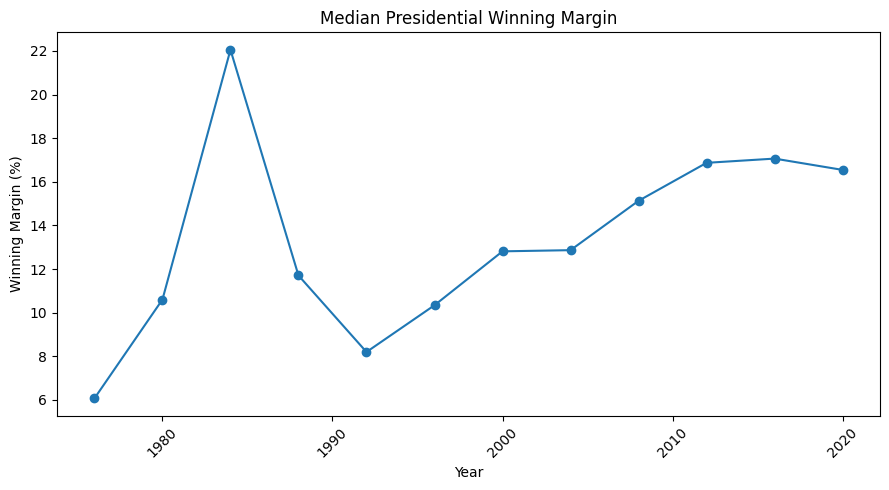

In [128]:
plt.figure(figsize=(9, 5))

plt.plot(
    year_margin.index,
    year_margin["median"] * 100,
    marker="o"
)

plt.title("Median Presidential Winning Margin")
plt.xlabel("Year")
plt.ylabel("Winning Margin (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

*The median winning margin changed noticeably across the election years. It was highest in 1984 at about 22%, while the lowest was in 1976 at about 6%. After reaching a low point in the early 1990s, the median margin generally increased, reaching around 17% in 2016 before falling slightly to about 16.6% in 2020.*

**Senate Seat Share by Party**

In [129]:
# Find the Senate winner in each state and year
sen_winner = sen.loc[
    sen.groupby(["year", "state", "special"])["candidatevotes"].idxmax()]

# Keep useful columns
sen_winner = sen_winner[["year", "state", "special", "party_simplified", "candidate"]]

# Count seats by party
seats = sen_winner.groupby(["year", "party_simplified"]).size().unstack(fill_value=0)

# Calculate seat percentage
seat_share = seats.div(seats.sum(axis=1), axis=0) * 100

print(seats)
print(seat_share.round(1))

party_simplified  DEMOCRAT  OTHER  REPUBLICAN
year                                         
1976                    21      1          11
1978                    16      0          19
1980                    13      0          20
1982                    20      0          13
1984                    17      0          16
1986                    20      0          14
1988                    19      0          14
1990                    18      0          17
1992                    21      0          14
1994                    14      0          21
1996                    13      0          21
1998                    18      0          16
2000                    19      0          15
2002                    12      0          22
2004                    15      0          19
2006                    22      2           9
2008                    20      0          15
2010                    13      1          23
2012                    23      2           8
2014                    12      0 

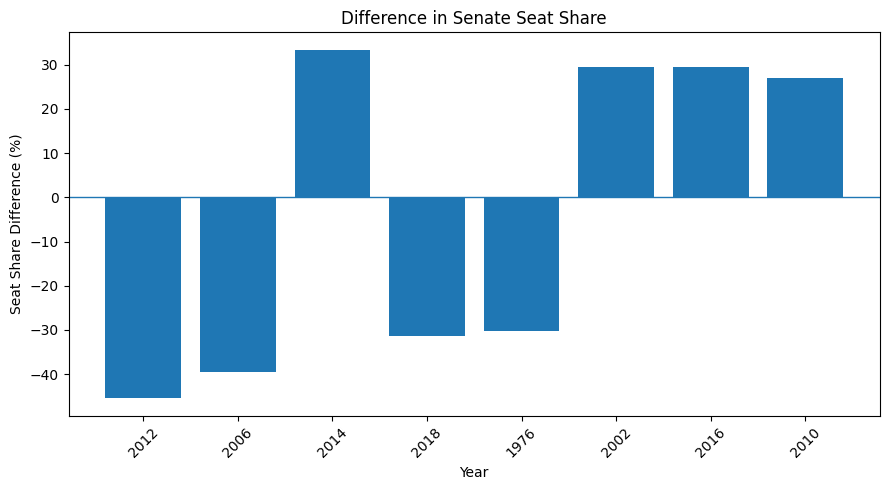

In [130]:
# Find the difference in seat share
party_gap = seat_share["REPUBLICAN"] - seat_share["DEMOCRAT"]

# Get the years with the biggest differences
top_years = party_gap.abs().nlargest(8).index

plt.figure(figsize=(9, 5))

plt.bar(top_years.astype(str),party_gap.loc[top_years])
plt.axhline(0, linewidth=1)
plt.title("Difference in Senate Seat Share")
plt.xlabel("Year")
plt.ylabel("Seat Share Difference (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

*The Senate seat share changes across different election years. The Democratic and Republican parties hold most of the seats, while other parties have a much smaller share. The results show changes in party representation over time.*

# Conclusion

The analysis shows that U.S. election results and party representation changed noticeably across the years. Presidential vote shares and Senate seat shares varied between Democratic and Republican parties, while split ticket voting also changed over time. The winning margin analysis shows that the competitiveness of presidential races differed across election years. Overall, the project demonstrates how data cleaning and exploratory analysis can be used to identify patterns and changes in U.S. election results over time.